# Random Forest Classifier

This notebook will explore the use of random forests to predict hyper- and hypothyroid conditions.

## Import Packages

In [1]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, fbeta_score, make_scorer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

## Read In Data

In [2]:
X_train = pd.read_csv('train.csv')
X_test = pd.read_csv('test.csv')
y_train = np.array(pd.read_csv('train_labels.csv')).reshape(-1,)
y_test = np.array(pd.read_csv('test_labels.csv')).reshape(-1,)

## Run RF Classifier

In [3]:
def score(y_true, y_pred):
    return np.array(fbeta_score(y_true, y_pred, average=None, beta=2)).min()

scorer = make_scorer(score)

### Using Balanced Class Weights

#### Find Optimal Num Trees

In [11]:
num_trees = range(1, 500, 10)
param_grid = {'rf__n_estimators': num_trees}
pipe = Pipeline(steps=[
    ('imputer', KNNImputer()),
    ('ss', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=6740, class_weight='balanced'))
])

rf = GridSearchCV(pipe, param_grid, cv=5, scoring=scorer)
rf = rf.fit(X_train, y_train)

The best number of trees is 361 with a f_2 score of 0.5876


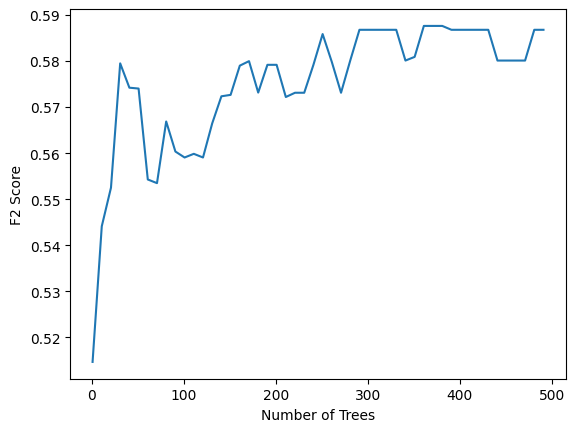

In [12]:
print(f'The best number of trees is {rf.best_params_["rf__n_estimators"]} with a f_2 score of {rf.best_score_:.4f}') 

plt.plot(num_trees, rf.cv_results_['mean_test_score'])
plt.xlabel('Number of Trees')
plt.ylabel('F2 Score')
plt.show()

#### Use Optimal Num Trees

In [ ]:
print(classification_report(y_test, rf.best_estimator_.predict(X_test)))
feature_importance_df = pd.DataFrame({'feature': rf.best_estimator_['rf'].feature_importances_, 'feature_name': X_train.columns}).sort_values(by='feature', ascending=False)
feature_importance_df.plot(kind='bar', x='feature_name', y='feature', legend=False, title='Feature Importance')
plt.show()

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1679
           1       0.94      0.99      0.97       119
           2       0.85      0.61      0.71        36

    accuracy                           0.99      1834
   macro avg       0.93      0.87      0.89      1834
weighted avg       0.99      0.99      0.99      1834



### Using SMOTE

#### Find Optimal Num Trees

In [15]:
num_trees = range(1, 500, 10)
param_grid = {'rf__n_estimators': num_trees}
pipe = Pipeline(steps=[
    ('imputer', KNNImputer()),
    ('ss', StandardScaler()),
    ('smote', SMOTE(random_state=6740)),
    ('rf', RandomForestClassifier(random_state=6740))
])

rf_smote = GridSearchCV(pipe, param_grid, cv=5, scoring=scorer)
rf_smote = rf_smote.fit(X_train, y_train)

The best number of trees is 71 with a f_2 score of 0.7930


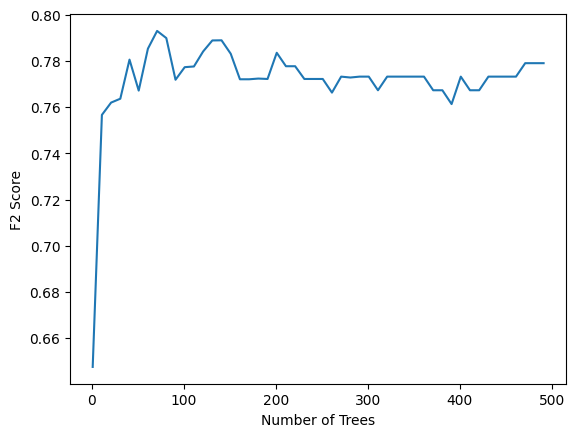

In [16]:
print(f'The best number of trees is {rf_smote.best_params_["rf__n_estimators"]} with a f_2 score of {rf_smote.best_score_:.4f}') 

plt.plot(num_trees, rf_smote.cv_results_['mean_test_score'])
plt.xlabel('Number of Trees')
plt.ylabel('F2 Score')
plt.show()

#### Use Optimal Num Trees

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1679
           1       0.91      1.00      0.95       119
           2       0.66      0.81      0.72        36

    accuracy                           0.98      1834
   macro avg       0.85      0.93      0.89      1834
weighted avg       0.98      0.98      0.98      1834



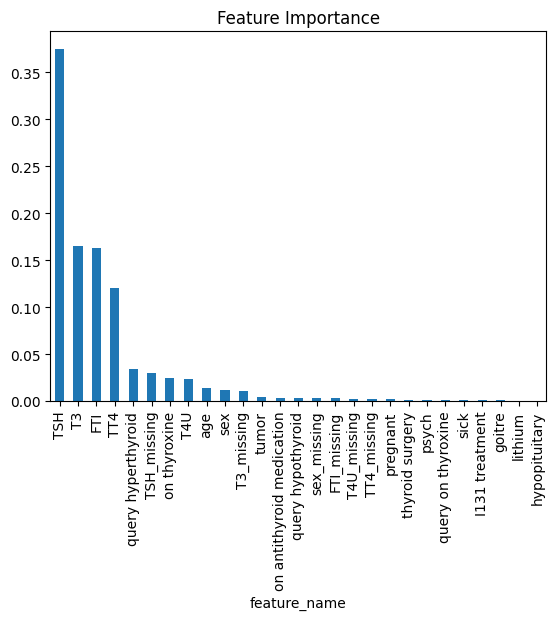

In [17]:
print(classification_report(y_test, rf_smote.best_estimator_.predict(X_test)))
feature_importance_df = pd.DataFrame({'feature': rf_smote.best_estimator_['rf'].feature_importances_, 'feature_name': X_train.columns}).sort_values(by='feature', ascending=False)
feature_importance_df.plot(kind='bar', x='feature_name', y='feature', legend=False, title='Feature Importance')
plt.show()

### Using SMOTEENN

#### Find Optimal Num Trees

In [18]:
num_trees = range(1, 500, 10)
param_grid = {'rf__n_estimators': num_trees}
pipe = Pipeline(steps=[
    ('imputer', KNNImputer()),
    ('ss', StandardScaler()),
    ('smoteenn', SMOTEENN(random_state=6740)),
    ('rf', RandomForestClassifier(random_state=6740))
])

rf_smoteenn = GridSearchCV(pipe, param_grid, cv=5, scoring=scorer)
rf_smoteenn = rf_smoteenn.fit(X_train, y_train)

The best number of trees is 121 with a f_2 score of 0.8037


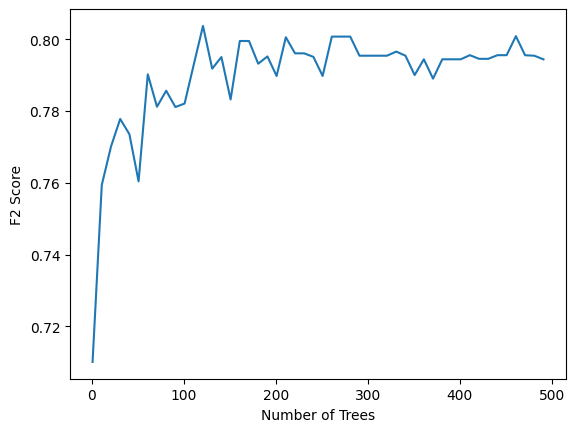

In [19]:
print(f'The best number of trees is {rf_smoteenn.best_params_["rf__n_estimators"]} with a f_2 score of {rf_smoteenn.best_score_:.4f}') 

plt.plot(num_trees, rf_smoteenn.cv_results_['mean_test_score'])
plt.xlabel('Number of Trees')
plt.ylabel('F2 Score')
plt.show()

#### Use Optimal Num Trees

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1679
           1       0.89      0.99      0.94       119
           2       0.59      0.92      0.72        36

    accuracy                           0.98      1834
   macro avg       0.83      0.96      0.88      1834
weighted avg       0.98      0.98      0.98      1834



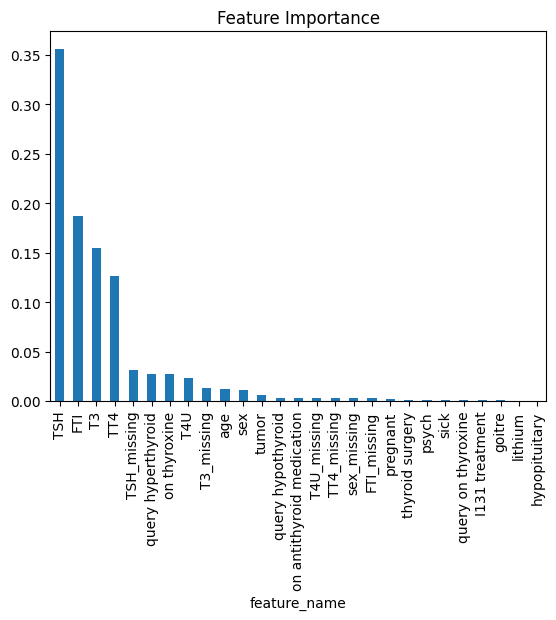

In [20]:
print(classification_report(y_test, rf_smoteenn.best_estimator_.predict(X_test)))
feature_importance_df = pd.DataFrame({'feature': rf_smoteenn.best_estimator_['rf'].feature_importances_, 'feature_name': X_train.columns}).sort_values(by='feature', ascending=False)
feature_importance_df.plot(kind='bar', x='feature_name', y='feature', legend=False, title='Feature Importance')
plt.show()